In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset_hour

In [2]:
raw_df = pd.read_csv('Huawei_Hourly_4G.csv')
df = clean_dataset_hour(raw_df)
df.head()

,Time,eNodeB_Name,Frequency_band,Cell_FDD_TDD_Indication,Cell_Name,LocalCell_Id,eNodeB_Function_Name,Integrity,CSSR_wo_VoLTE,DRC_wo_VoLTE,...,Avg_DL_PRB_Usage,Avg_UL_PRB_Usage,Avg_Traffic_User,DRC_wo_VoLTE_missing,Avg_DL_User_Thrput_kbps_missing,Avg_UL_User_Thrput_kbps_missing,Avg_DL_Traffic_Active_User_missing,Avg_UL_Traffic_Active_User_missing,Avg_DL_PRB_Usage_missing,Avg_UL_PRB_Usage_missing
0,2025-07-01,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_3_L800,13,0001_KKO_KATI_4G,100%,99.6441,0.7339,...,29.6678,10.2067,16.3828,False,False,False,False,False,False,False
1,2025-07-01,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_2_L800,12,0001_KKO_KATI_4G,100%,99.2578,0.0000,...,63.5563,11.4299,20.5981,False,False,False,False,False,False,False
2,2025-07-01,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_1_L800,11,0001_KKO_KATI_4G,100%,98.8347,0.0000,...,33.9714,9.4250,11.8103,False,False,False,False,False,False,False
3,2025-07-01,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_3_L800,13,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,100.0000,0.6250,...,19.6524,11.1020,8.3372,False,False,False,False,False,False,False
4,2025-07-01,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_2_L800,12,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.3028,0.0000,...,27.0570,13.0863,14.4222,False,False,False,False,False,False,False


### General Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nDetailed info:")
df.info()

Shape: (1048569, 26)

Data Types:
float64           11
bool               7
string[python]     4
category           1
datetime64[ns]     1
category           1
category           1
Name: count, dtype: int64

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048569 entries, 0 to 1048568
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   Time                                1048569 non-null  datetime64[ns]
 1   eNodeB_Name                         1048569 non-null  string        
 2   Frequency_band                      1048569 non-null  category      
 3   Cell_FDD_TDD_Indication             1048569 non-null  category      
 4   Cell_Name                           1048569 non-null  string        
 5   LocalCell_Id                        1048569 non-null  string        
 6   eNodeB_Function_Name                1048569 non-null  string       

In [4]:
# Missing flags summary
missing_flag_cols = ['DRC_wo_VoLTE_missing', 'Avg_DL_User_Thrput_kbps_missing', 'Avg_UL_User_Thrput_kbps_missing',
                    'Avg_DL_Traffic_Active_User_missing', 'Avg_UL_Traffic_Active_User_missing', 'Avg_DL_PRB_Usage_missing',
                    'Avg_UL_PRB_Usage_missing']

# Count of True/False per flag
for col in missing_flag_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))

# Count rows with any missing flag True
df['any_missing'] = df[missing_flag_cols].any(axis=1)
print("\nRows with any missing flag True:", df['any_missing'].sum())


DRC_wo_VoLTE_missing value counts:
DRC_wo_VoLTE_missing
False    1013422
True       35147
Name: count, dtype: int64

Avg_DL_User_Thrput_kbps_missing value counts:
Avg_DL_User_Thrput_kbps_missing
False    1006841
True       41728
Name: count, dtype: int64

Avg_UL_User_Thrput_kbps_missing value counts:
Avg_UL_User_Thrput_kbps_missing
False    1016185
True       32384
Name: count, dtype: int64

Avg_DL_Traffic_Active_User_missing value counts:
Avg_DL_Traffic_Active_User_missing
False    1045319
True        3250
Name: count, dtype: int64

Avg_UL_Traffic_Active_User_missing value counts:
Avg_UL_Traffic_Active_User_missing
False    1045319
True        3250
Name: count, dtype: int64

Avg_DL_PRB_Usage_missing value counts:
Avg_DL_PRB_Usage_missing
False    1036178
True       12391
Name: count, dtype: int64

Avg_UL_PRB_Usage_missing value counts:
Avg_UL_PRB_Usage_missing
False    1036178
True       12391
Name: count, dtype: int64

Rows with any missing flag True: 44984


In [5]:
# Categorical summary
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    print(f"\nColumns: {col}")
    print(df[col].value_counts(dropna=False))


Columns: Frequency_band
Frequency_band
20    401812
3     314593
28    199450
7     131256
40      1458
Name: count, dtype: int64

Columns: Cell_FDD_TDD_Indication
Cell_FDD_TDD_Indication
CELL_FDD    1047111
CELL_TDD       1458
Name: count, dtype: int64

Columns: Integrity
Integrity
100%    1048569
Name: count, dtype: int64


In [6]:
# Time summary
print(f"\nTime Range: {df['Time'].min()} to {df['Time'].max()}")
print("Time Frequency Breakdown:")
print(df['Time'].dt.to_period('D').value_counts().sort_index())


Time Range: 2025-07-01 00:00:00 to 2025-07-04 09:00:00
Time Frequency Breakdown:
Time
2025-07-01    308989
2025-07-02    309229
2025-07-03    309207
2025-07-04    121144
Freq: D, Name: count, dtype: int64


In [7]:
# Descriptive stats for numeric columns
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CSSR_wo_VoLTE,1048569.0,96.089008,18.538014,0.0,99.6612,99.9188,100.0000,100.0000
DRC_wo_VoLTE,1048569.0,0.243120,1.018843,0.0,0.0000,0.0371,0.2270,100.0000
Avg_DL_User_Thrput_kbps,1048569.0,27208.167536,17608.368835,0.0,14981.3333,24840.6772,36704.8739,284339.4946
UL_Traffic_Volume_GBytes,1048569.0,0.300956,0.447070,0.0,0.0288,0.1323,0.3969,14.7601
Avg_UL_User_Thrput_kbps,1048569.0,3403.181867,2634.615348,0.0,1911.2162,2836.9248,4200.8185,164536.0000
DL_Traffic_Volume_GBytes,1048569.0,2.678620,3.444753,0.0,0.3047,1.3180,3.7877,62.8210
Avg_DL_Traffic_Active_User,1048569.0,1.041076,4.509720,0.0,0.0568,0.2342,0.7113,259.0458
Avg_UL_Traffic_Active_User,1048569.0,0.812956,2.372743,0.0,0.1001,0.3632,0.9634,276.8261
Avg_DL_PRB_Usage,1048569.0,21.769461,23.451950,0.0,4.4682,12.7772,30.7107,99.9776
Avg_UL_PRB_Usage,1048569.0,12.364754,9.508467,0.0,6.3749,8.8997,15.4589,98.6130


### Univariate Analysis

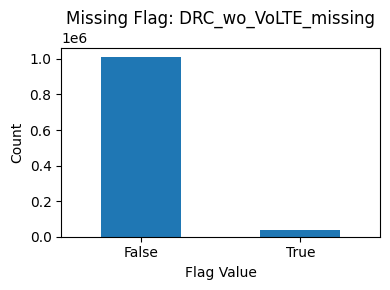

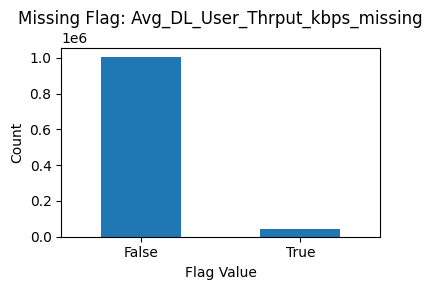

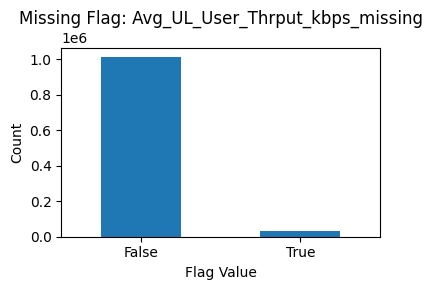

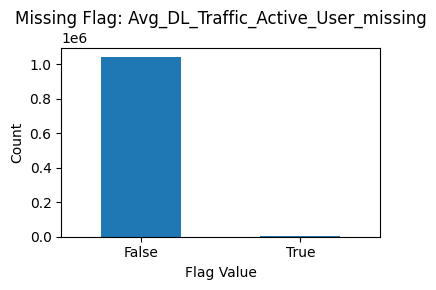

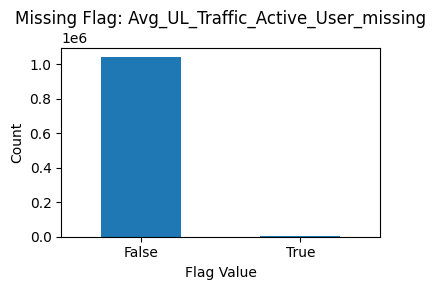

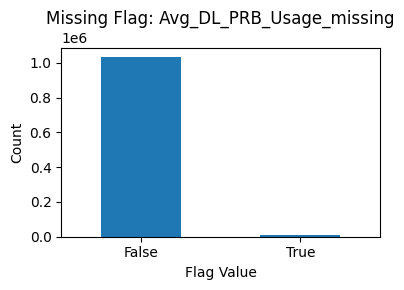

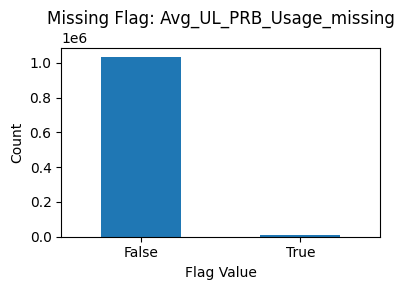

In [8]:
# Bar plots
for col in missing_flag_cols:
    plt.figure(figsize=(4, 3))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Missing Flag: {col}')
    plt.xlabel('Flag Value')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

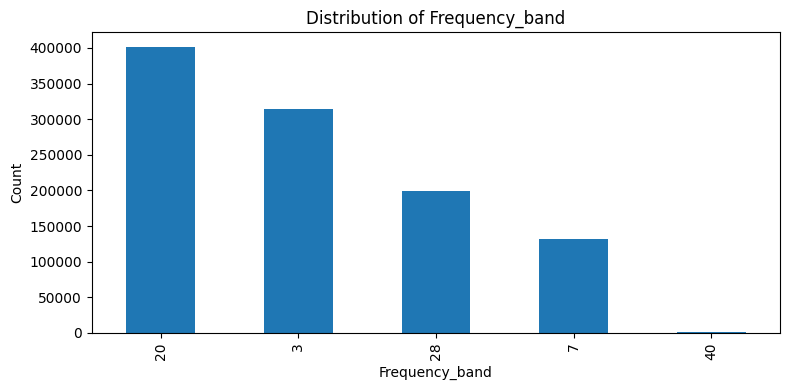

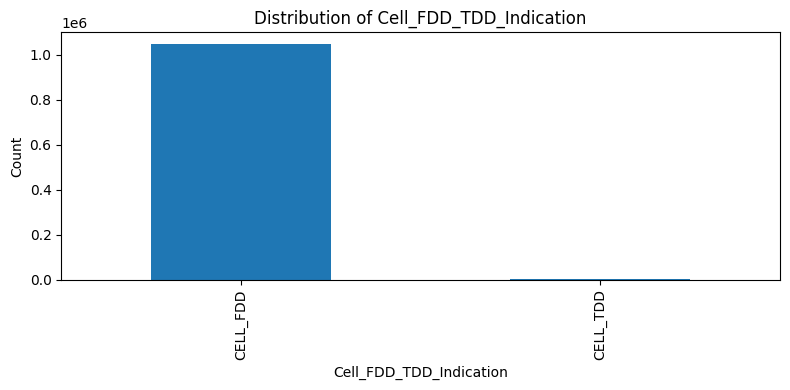

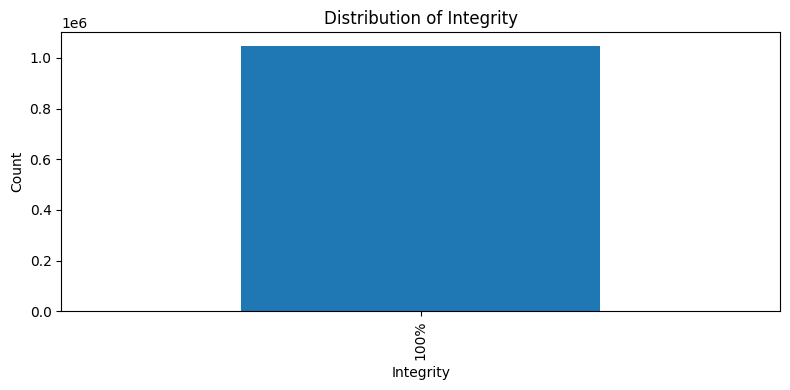

In [9]:
# Bar plots
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

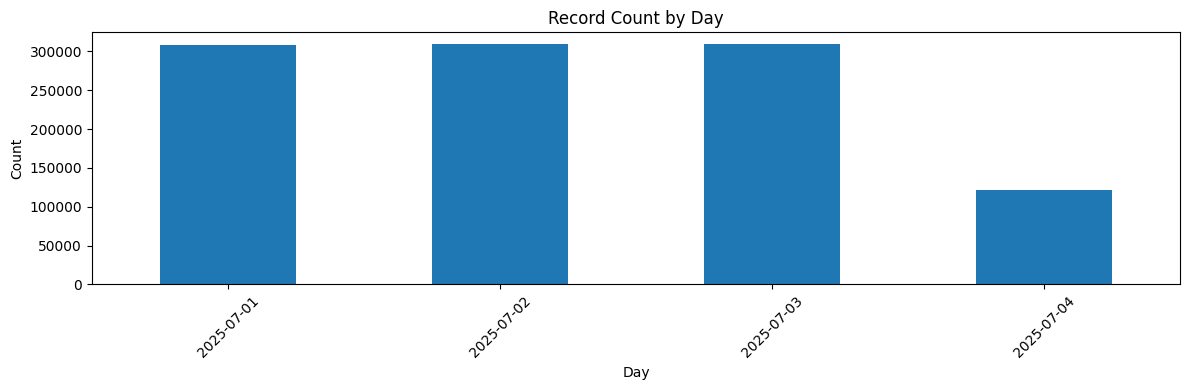

In [10]:
# Time summary
df['Time'].dt.to_period('D').value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('Record Count by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

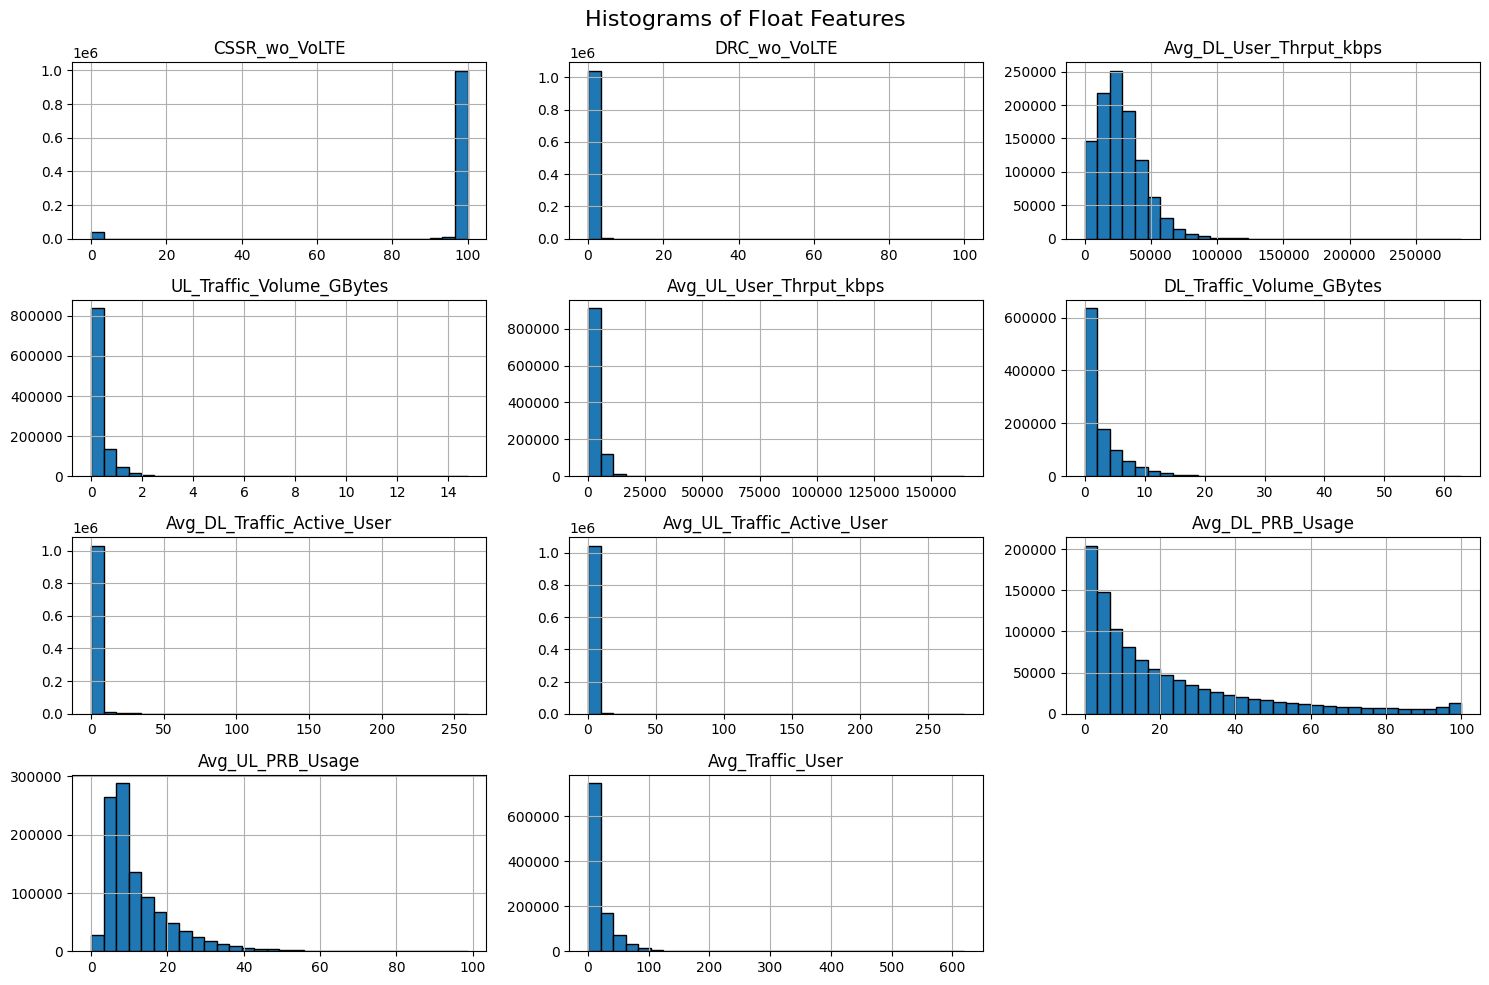

In [11]:
# Float columns histograms
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Float Features', fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate Analysis

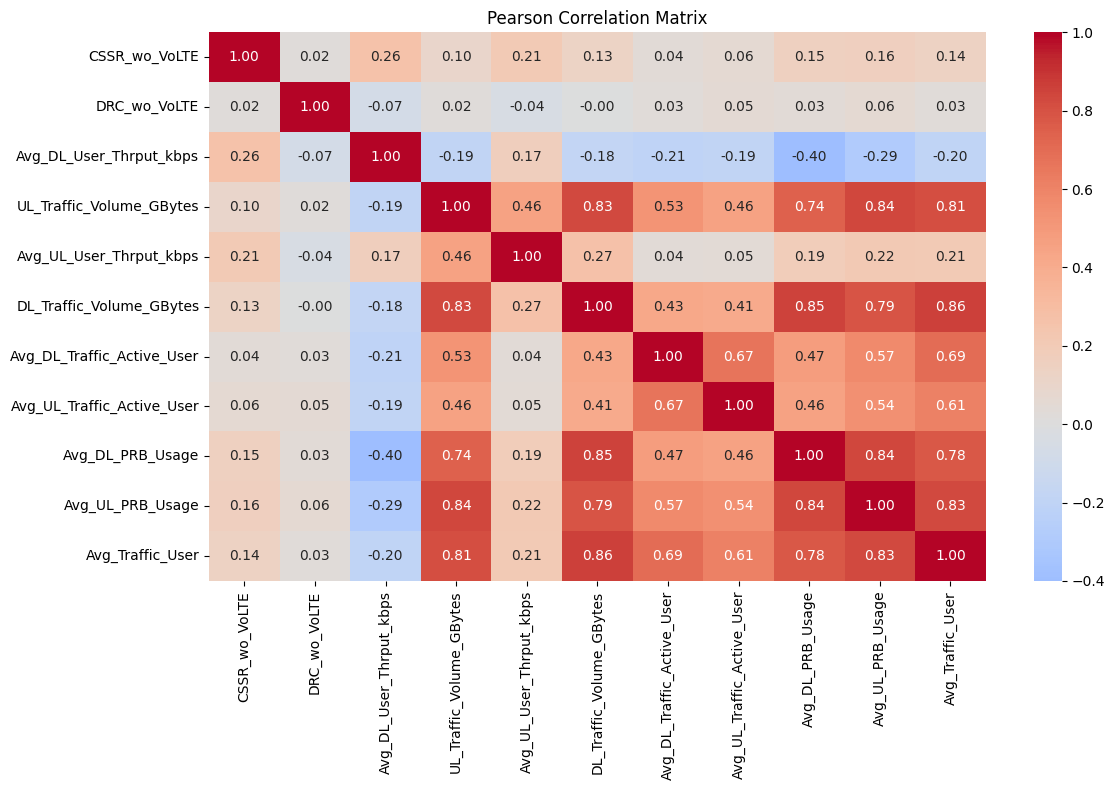

In [12]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

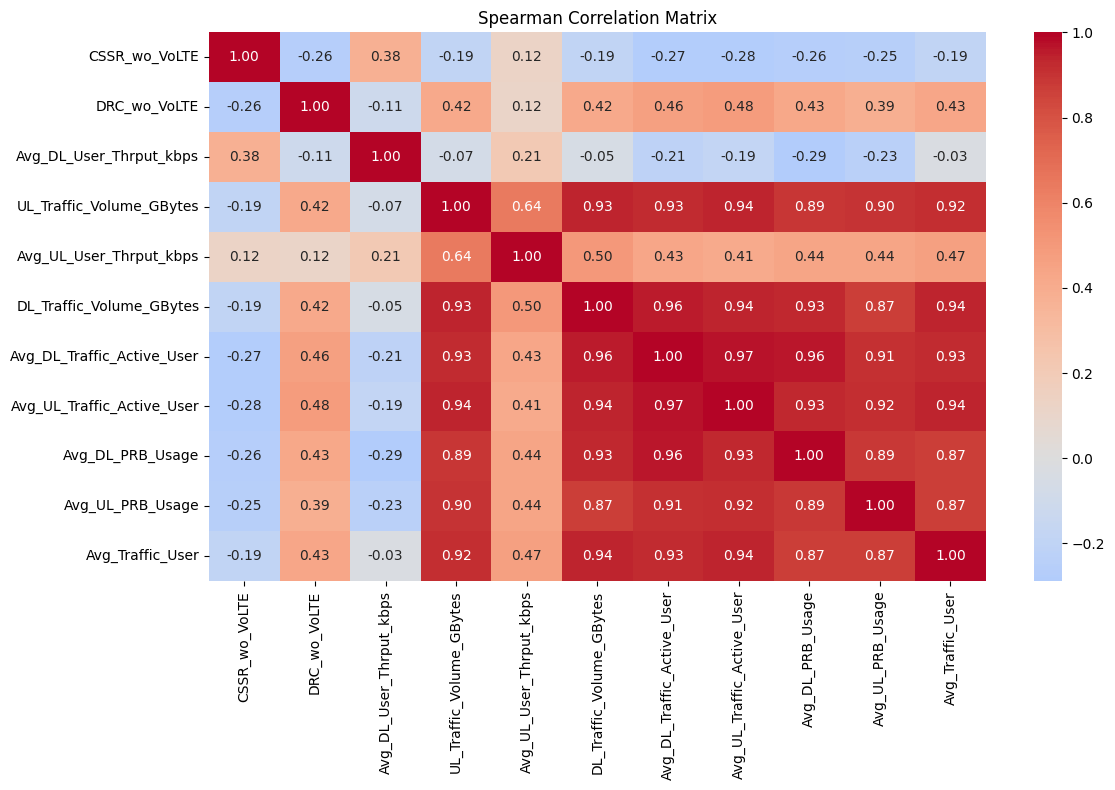

In [13]:
plt.figure(figsize=(12, 8))
corr_spearman = df[numeric_cols].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9876\1392898942.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_time = df.set_index('Time').resample('H').mean(numeric_only=True)


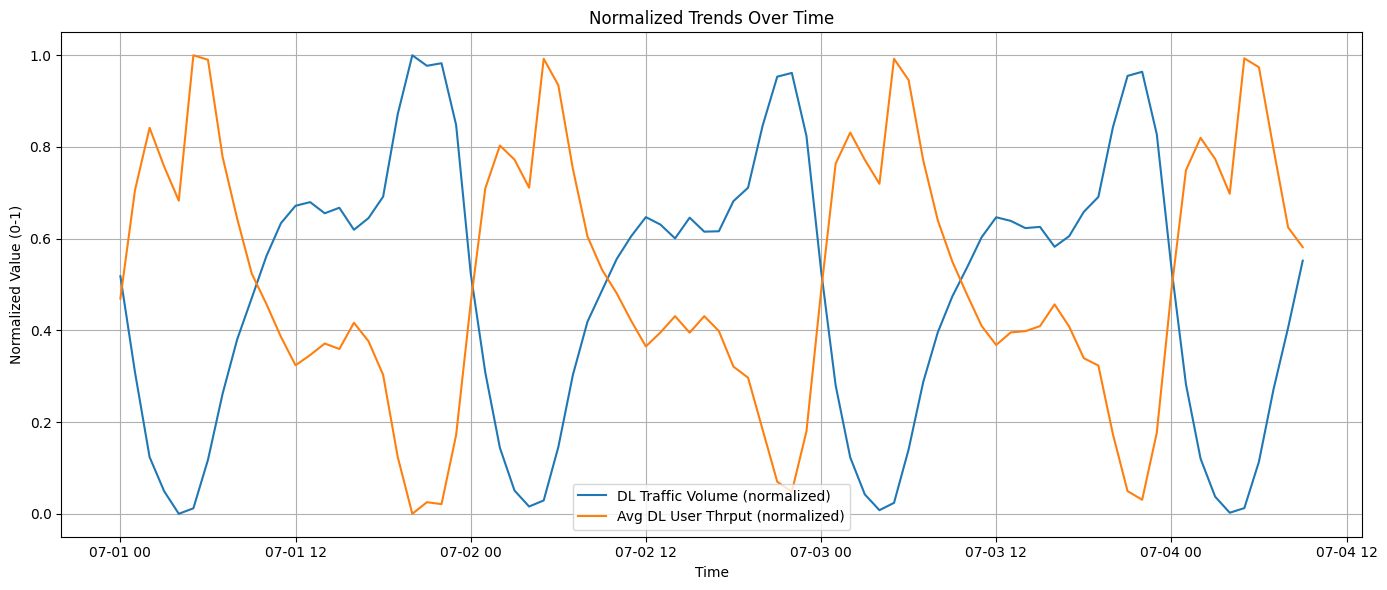

In [14]:
df_time = df.set_index('Time').resample('H').mean(numeric_only=True)

df_time_norm = df_time[['DL_Traffic_Volume_GBytes', 'Avg_DL_User_Thrput_kbps']].apply(lambda x: 
                                                                                      (x - x.min()) / (x.max() - x.min()))

plt.figure(figsize=(14, 6))
plt.plot(df_time_norm.index, df_time_norm['DL_Traffic_Volume_GBytes'], label='DL Traffic Volume (normalized)')
plt.plot(df_time_norm.index, df_time_norm['Avg_DL_User_Thrput_kbps'], label='Avg DL User Thrput (normalized)')
plt.title('Normalized Trends Over Time')
plt.xlabel('Time')
plt.ylabel('Normalized Value (0-1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Dimensionality Reduction & Redundancy Checks

In [15]:
from sklearn.preprocessing import StandardScaler

# Scale the float features
X_numeric = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

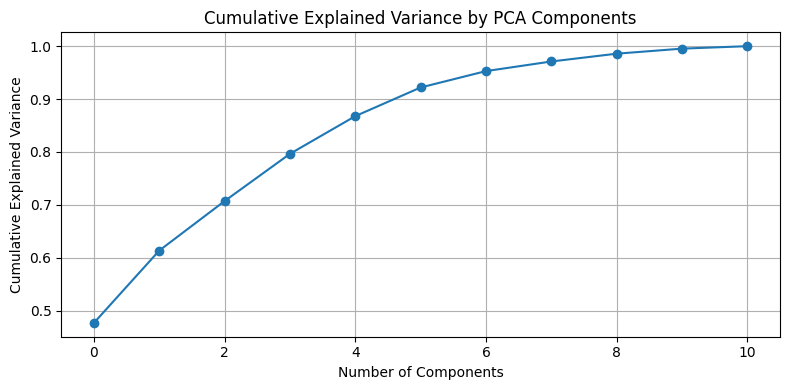

In [16]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained_var), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

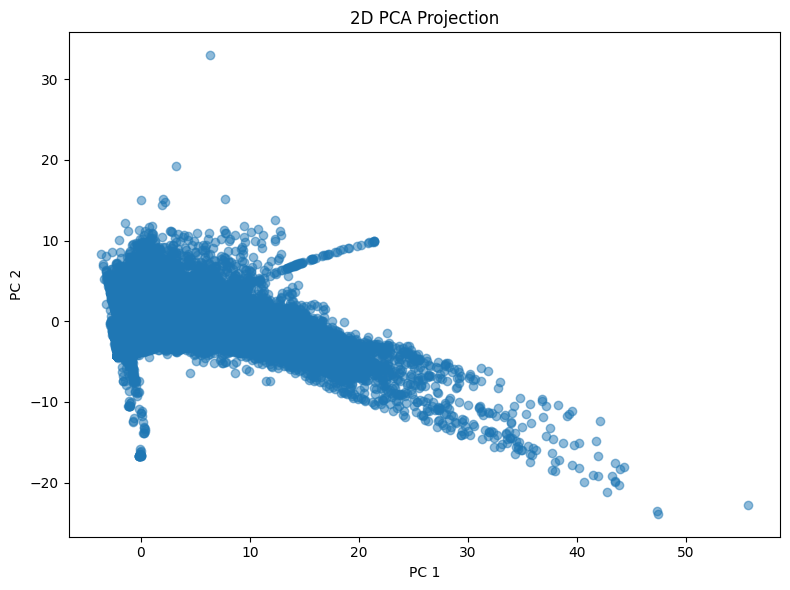

In [17]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('2D PCA Projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


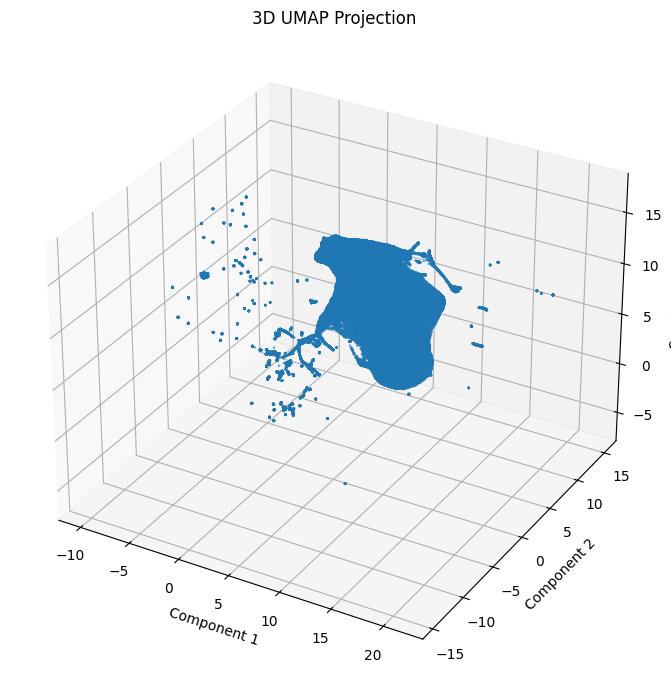

In [18]:
import umap
from sklearn.utils import resample

umap_model = umap.UMAP(n_neighbors=15, n_components=3, random_state=42)
X_sample = X_scaled[308989 : 618218]
X_umap = umap_model.fit_transform(X_sample)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], alpha=0.5, s=1)
ax.set_title('3D UMAP Projection')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.neighbors import NearestNeighbors

def hopkins(X, sampling_size=0.1):
    if isinstance(X, pd.DataFrame):
        X = X.values

    n_samples = X.shape[0]
    d = X.shape[1]

    m = sampling_size if isinstance(sampling_size, int) else int(sampling_size * n_samples)
    np.random.seed(42)

    random_indices = np.random.choice(n_samples, m, replace=False)
    X_sample = X[random_indices]

    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_random = np.random.uniform(X_min, X_max, (m, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    u_distances, _ = nbrs.kneighbors(X_random, n_neighbors=1)
    u_sum = np.sum(u_distances)

    w_distances, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    w_sum = np.sum(w_distances[:, 1])

    hopkins_score = u_sum / (u_sum + w_sum)

    return hopkins_score

In [20]:
score = hopkins(X_scaled)
print(f"Hopkins Statistics: {score:.4f}")

Hopkins Statistics: 0.9970


In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels):
    """
    Evaluate clustering performance using:
    - Silhouette Score
    - Davies-Bouldin Index
    - Calinski-Harabasz index
    """
    
    # Filter out noise points (e.g., from DBSCAN) if present
    if -1 in labels:
        X_valid = X[labels != -1]
        labels_valid = labels[labels != -1]
    else:
        X_valid = X
        labels_valid = labels

    results = {}

    silhouette_sample_size = 10000
    # Silhouette Score: compute on a sample
    try:
        X_sil, labels_sil = resample(X_valid, labels_valid, n_samples=silhouette_sample_size, random_state=42)
        results['Silhouette Score'] = silhouette_score(X_sil, labels_sil)
    except Exception as e:
        results['Silhouette Score'] = f"Error: {e}"

    try:
        results['Davies-Bouldin Index'] = davies_bouldin_score(X_valid, labels_valid)
    except Exception as e:
        results['Davies-Bouldin Index'] = f"Error: {e}"

    try:
        results['Calinski-Harabasz Index'] = calinski_harabasz_score(X_valid, labels_valid)
    except Exception as e:
        results['Calinski-Harabasz Index'] = f"Error: {e}"

    for metric, score in results.items():
        print(f"{metric}: {score}")

    return results

### K-Means

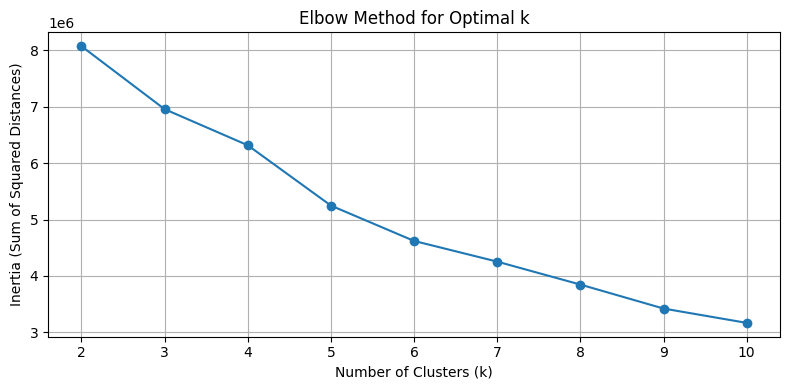

In [23]:
from sklearn.cluster import KMeans

# Elbow Method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = kmeans_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, kmeans_labels)

Silhouette Score: 0.2786969923790173
Davies-Bouldin Index: 1.0914476365610215
Calinski-Harabasz Index: 314095.4699828943


### GMM

In [25]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

df['cluster_gmm'] = gmm_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, gmm_labels)

Silhouette Score: 0.06495950171461856
Davies-Bouldin Index: 2.7682843960083057
Calinski-Harabasz Index: 148140.9457604592


### HDBSCAN

In [26]:
import hdbscan

hdbscan = hdbscan.HDBSCAN(min_cluster_size=500)
hdbscan_labels = hdbscan.fit_predict(X_scaled)

df['cluster_hdbscan'] = hdbscan_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(X_scaled, hdbscan_labels)

C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.554059635169051
Davies-Bouldin Index: 0.35146030283854185
Calinski-Harabasz Index: 45255.87586976988


### Feature Selection

In [27]:
def compute_knowledge_components(X_scaled):
    components = pd.DataFrame(index=X_scaled.index)

    # PC1: Accessibility
    components["PC1_Accessibility"] = X_scaled["CSSR_wo_VoLTE"]

    # PC2: Maintaining
    components["PC2_Maintaining"] = X_scaled["DRC_wo_VoLTE"]

    # PC3: DL Performance
    components["PC3_DL_Performance"] = X_scaled["Avg_DL_User_Thrput_kbps"]

    # PC4: DL Volume
    components["PC4_DL_Volume"] = (X_scaled["DL_Traffic_Volume_GBytes"] + X_scaled["Avg_DL_Traffic_Active_User"] +
                                   X_scaled["Avg_DL_PRB_Usage"]) / 3

    # PC5: UL Performance
    components["PC5_UL_Performance"] = X_scaled["Avg_UL_User_Thrput_kbps"]

    # PC6: UL Volume
    components["PC6_UL_Volume"] = (X_scaled["UL_Traffic_Volume_GBytes"] + X_scaled["Avg_UL_Traffic_Active_User"] +
                                   X_scaled["Avg_UL_PRB_Usage"]) / 3

    # PC7: Users
    components["PC7_Users"] = X_scaled["Avg_Traffic_User"]

    return components

In [28]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)
X_sample_df = pd.DataFrame(X_sample, columns=X_numeric.columns)

component_scores = compute_knowledge_components(X_scaled_df)
C_sample = compute_knowledge_components(X_sample_df)

print(component_scores.head())

   PC1_Accessibility  PC2_Maintaining  PC3_DL_Performance  PC4_DL_Volume  \
0           0.191773         0.481704           -1.081587      -0.032912   
1           0.170935        -0.238623           -0.808008       1.142350   
2           0.148112        -0.238623           -1.082738       0.015747   
3           0.210972         0.374818           -0.366181      -0.154846   
4           0.173362        -0.238623           -0.002280       0.168470   

   PC5_UL_Performance  PC6_UL_Volume  PC7_Users  
0           -0.086710      -0.164194  -0.077038  
1           -0.541092      -0.013664   0.087075  
2           -0.618682      -0.263955  -0.255058  
3           -0.122196      -0.211146  -0.390276  
4           -0.603363      -0.152637  -0.153370  


In [29]:
score = hopkins(component_scores)

pca = PCA(n_components=6)
C_pca = pca.fit_transform(C_sample)

score_c = hopkins(C_sample)
score_pca = hopkins(C_pca)

print(f"Hopkins Statistics: {score:.4f}")
print(f"Hopkins Statistics: {score_c:.4f}")
print(f"Hopkins Statistics: {score_pca:.4f}")

Hopkins Statistics: 0.9976
Hopkins Statistics: 0.9960
Hopkins Statistics: 0.9970


In [30]:
pc1 = C_sample['PC1_Accessibility']
pc2 = C_sample['PC2_Maintaining']
pc3 = C_sample['PC3_DL_Performance']
pc4 = C_sample['PC4_DL_Volume']
pc5 = C_sample['PC5_UL_Performance']
pc6 = C_sample['PC6_UL_Volume']
pc7 = C_sample['PC7_Users']

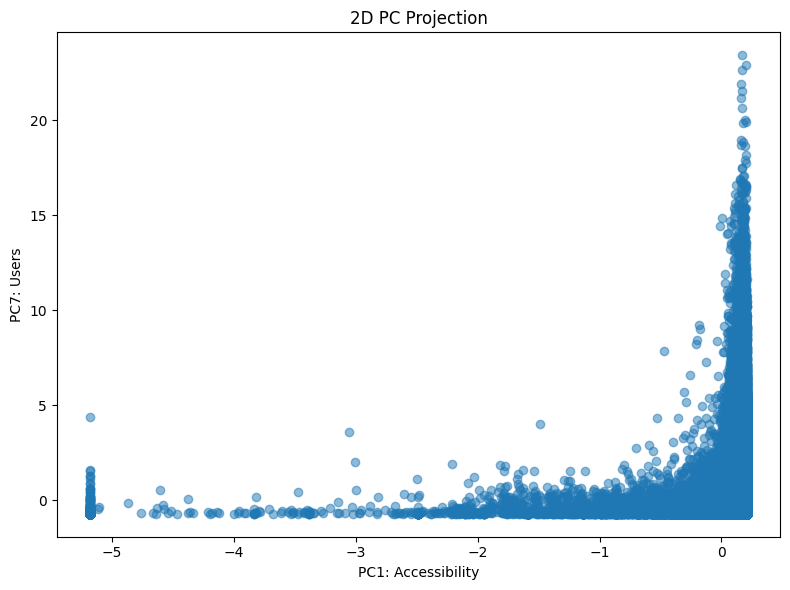

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(component_scores['PC1_Accessibility'], component_scores['PC7_Users'], alpha=0.5)
plt.title('2D PC Projection')
plt.xlabel('PC1: Accessibility')
plt.ylabel('PC7: Users')
plt.tight_layout()
plt.show()

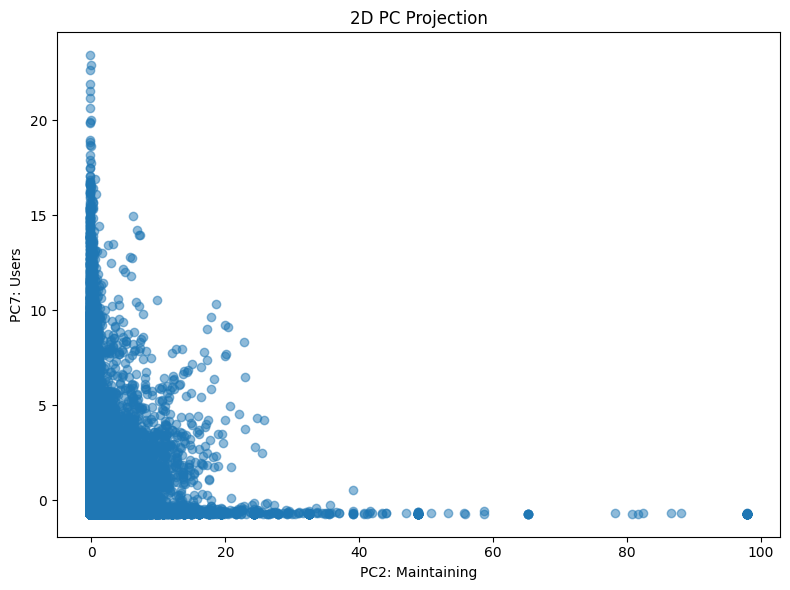

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(component_scores['PC2_Maintaining'], component_scores['PC7_Users'], alpha=0.5)
plt.title('2D PC Projection')
plt.xlabel('PC2: Maintaining')
plt.ylabel('PC7: Users')
plt.tight_layout()
plt.show()

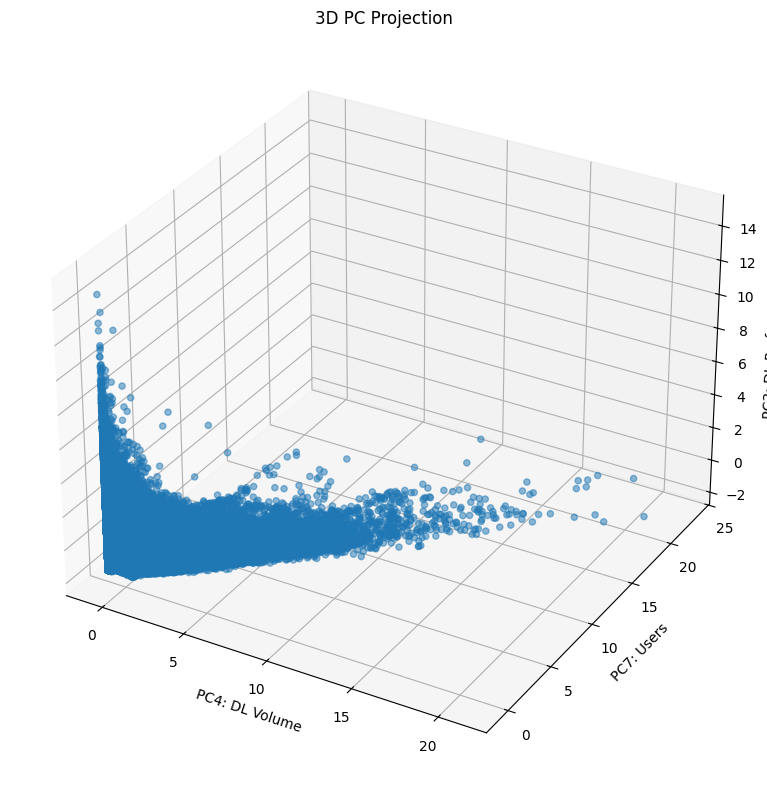

In [33]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    component_scores['PC4_DL_Volume'],
    component_scores['PC7_Users'],
    component_scores['PC3_DL_Performance'],
    alpha=0.5
)

ax.set_title('3D PC Projection')
ax.set_xlabel('PC4: DL Volume')
ax.set_ylabel('PC7: Users')
ax.set_zlabel('PC3: DL Performance')
plt.tight_layout()
plt.show()

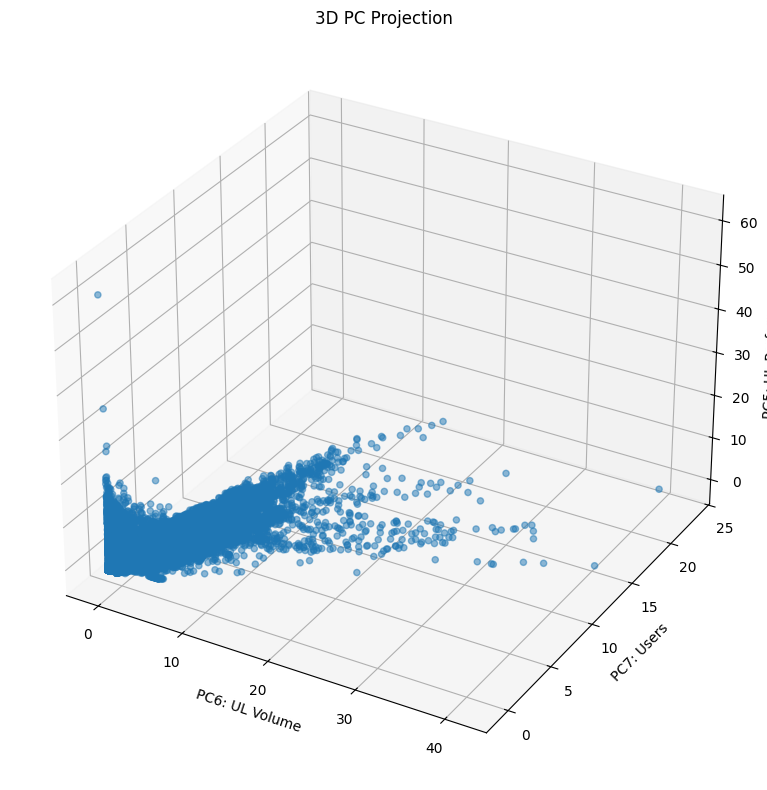

In [34]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    component_scores['PC6_UL_Volume'],
    component_scores['PC7_Users'],
    component_scores['PC5_UL_Performance'],
    alpha=0.5
)

ax.set_title('3D PC Projection')
ax.set_xlabel('PC6: UL Volume')
ax.set_ylabel('PC7: Users')
ax.set_zlabel('PC5: UL Performance')
plt.tight_layout()
plt.show()

### K-means

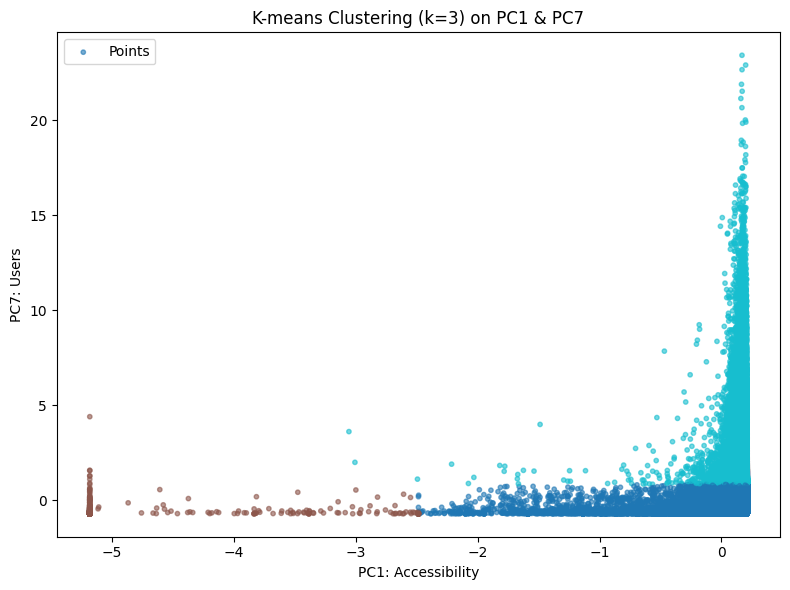

In [35]:
from sklearn.cluster import KMeans

A = component_scores[['PC1_Accessibility', 'PC7_Users']].values

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(A)

# Plot the clusters and centroids
plt.figure(figsize=(8, 6))
plt.scatter(A[:, 0], A[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10, label='Points')
plt.xlabel('PC1: Accessibility')
plt.ylabel('PC7: Users')
plt.title(f'K-means Clustering (k={k}) on PC1 & PC7')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(A, kmeans_labels)

Silhouette Score: 0.7387568859606066
Davies-Bouldin Index: 0.4162204158422769
Calinski-Harabasz Index: 2106995.6389762755


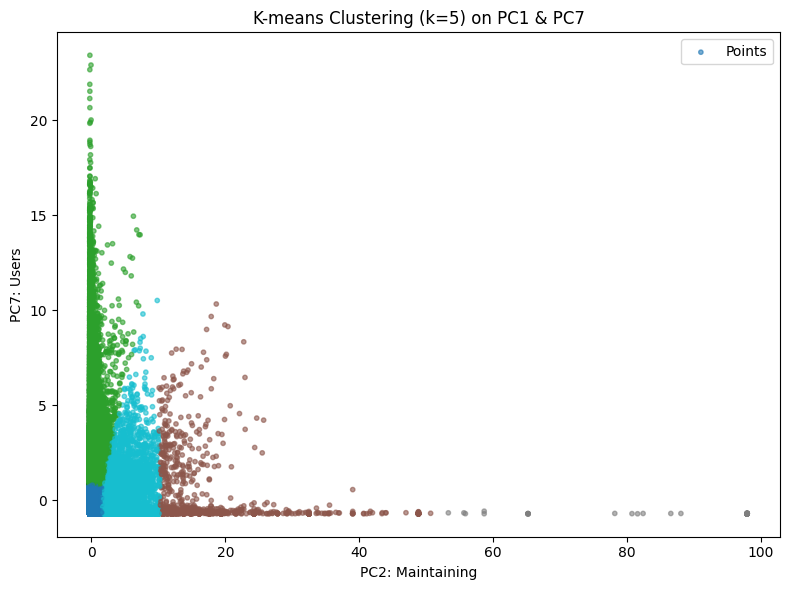

In [37]:
B = component_scores[['PC2_Maintaining', 'PC7_Users']].values

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(B)

# Plot the clusters and centroids
plt.figure(figsize=(8, 6))
plt.scatter(B[:, 0], B[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10, label='Points')
plt.xlabel('PC2: Maintaining')
plt.ylabel('PC7: Users')
plt.title(f'K-means Clustering (k={k}) on PC1 & PC7')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(B, kmeans_labels)

Silhouette Score: 0.677716547323876
Davies-Bouldin Index: 0.5528648370822333
Calinski-Harabasz Index: 579355.3061141279


C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9876\2122468307.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9876\2122468307.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


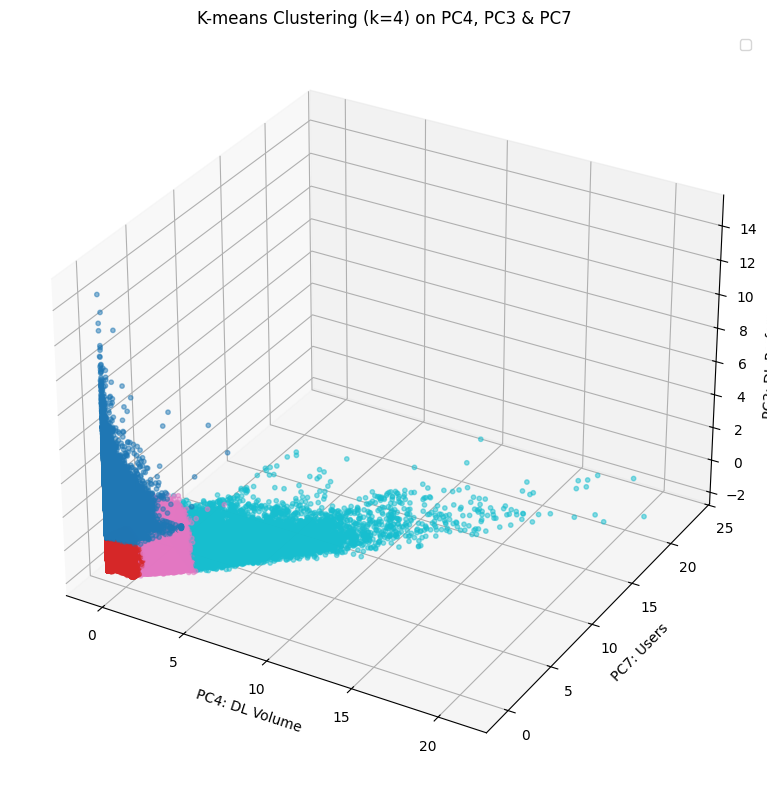

In [39]:
C = component_scores[['PC4_DL_Volume', 'PC7_Users', 'PC3_DL_Performance']].values

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(C)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    C[:, 0], C[:, 1], C[:, 2],
    c=kmeans_labels, cmap='tab10', alpha=0.5, s=10
)

ax.set_xlabel('PC4: DL Volume')
ax.set_ylabel('PC7: Users')
ax.set_zlabel('PC3: DL Performance')
ax.set_title(f'K-means Clustering (k={k}) on PC4, PC3 & PC7')
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(C, kmeans_labels)

Silhouette Score: 0.4225504010078358
Davies-Bouldin Index: 0.7888698260729479
Calinski-Harabasz Index: 776697.8220612173


C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9876\1593887821.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\hkizamou\AppData\Local\Temp\ipykernel_9876\1593887821.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


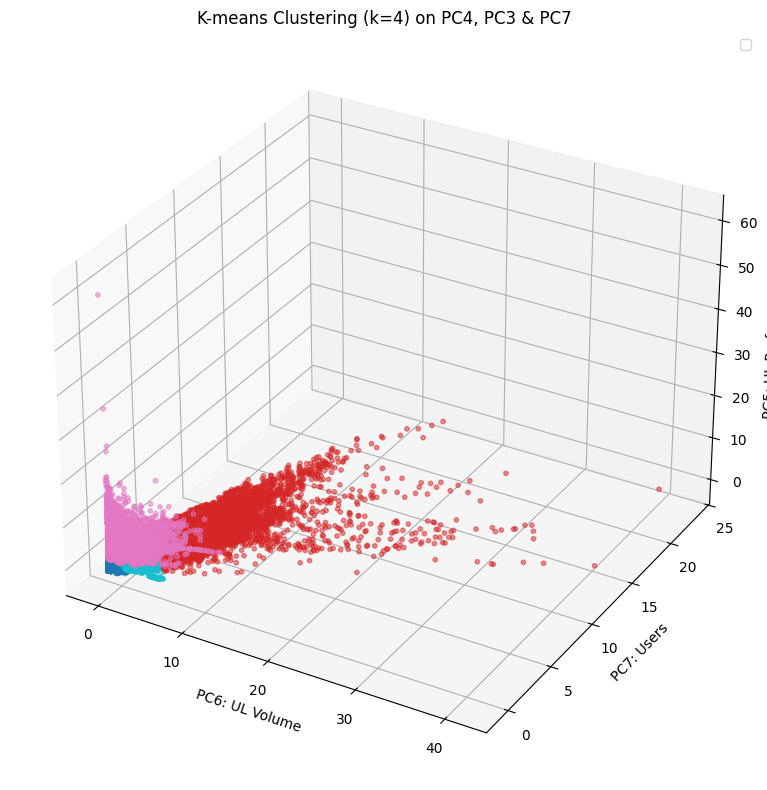

In [41]:
D = component_scores[['PC6_UL_Volume', 'PC7_Users', 'PC5_UL_Performance']].values

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(D)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    D[:, 0], D[:, 1], D[:, 2],
    c=kmeans_labels, cmap='tab10', alpha=0.5, s=10
)

ax.set_xlabel('PC6: UL Volume')
ax.set_ylabel('PC7: Users')
ax.set_zlabel('PC5: UL Performance')
ax.set_title(f'K-means Clustering (k={k}) on PC4, PC3 & PC7')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(D, kmeans_labels)

Silhouette Score: 0.5073376603320245
Davies-Bouldin Index: 0.8314663924729292
Calinski-Harabasz Index: 625494.5301022639


### HDBSCAN

In [43]:
import hdbscan

C = component_scores[['PC4_DL_Volume', 'PC7_Users', 'PC3_DL_Performance']].values

hdbscan = hdbscan.HDBSCAN(min_cluster_size=500)
hdbscan_labels = hdbscan.fit_predict(C)

C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [44]:
unique_labels = np.unique(hdbscan_labels)
print(unique_labels)

n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
print(f"Estimated number of clusters: {n_clusters}")

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(C, hdbscan_labels)

[-1  0  1  2  3]
Estimated number of clusters: 4
Silhouette Score: 0.43263265553743296
Davies-Bouldin Index: 0.3734675778451185
Calinski-Harabasz Index: 50052.25462730477
